In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, deque
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import silhouette_score, mean_absolute_error,root_mean_squared_error, r2_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.mixture import GaussianMixture

# 1. Answer the questions

## 1) Propose a new method to initialize cluster centroids for K-means. List the advantages and diadvantages of Forge, Random Partiton, and your iwn initializations.

Forge - случайным образом выбираем центроиды кластеров из данных точек. 

* плюсы: так как мы выбираем точку из реальных данных, и это будет существующая точка, то мы точно попадём в облако данных, чем если бы точка выбиралась совершенно рандомно.
* минусы: начальный выбор точек может быть таким, что кластеры разобьются некорректно именно из-за начального выбора центроидов

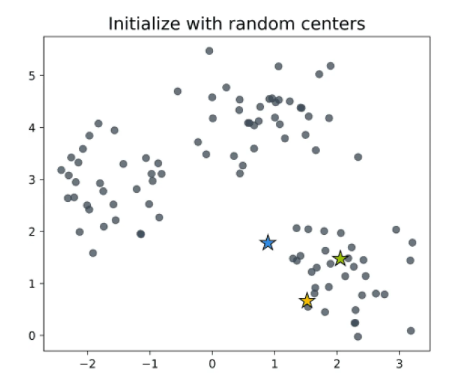, 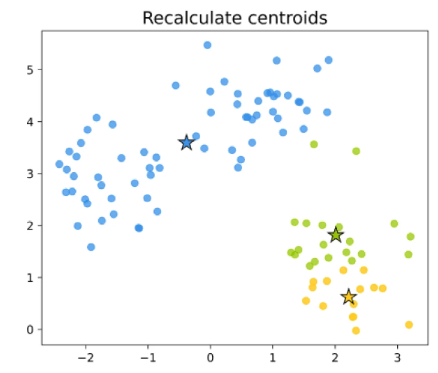

Random Partiton - все точки пространсва случайным образом распределяем по кластерам, и центры выбираем как среднее всех точек кластеров. 

* минусы - точка центроида не соответсвует реальной точке данных, а просто некотороая точка в пространсвте, поэтому точка центроида может попадать в пустое простарноство, при определённом слуае разбиения. Также часто бывает, что все центроиды находят рядом в середине, и либо это хорошо срабатывает и цетроиды корректно расходятся, но может быть и такое, что точки сольются

* плюсы - вычисление по всем данным, что в основом даёт хорошее математичсекое ожидание начальных цетров, в сравнении с другими более сложными методами. Простоя реализация метода. Меньше шаносв на мертвые цетры , которые стоят слишком рядом, чем в метде Forge

Некотора смесь разных методов: 

например дано 3 кластера, тогда мы решаем определить по 10 точек каждого кластера, причем 1 точку выбрием наугад, и помечаем кластер 1, потом ищём остальные 9 точек которые назовём также кластером 1, но при этом будем выбирать не любую точку, а только есть она на относительно близком расстоянии к начлаьной точке, и по итогу будет 10 точек кластерра 10 относитлньо билзких. Дальше для выбора точки кластера 2 будет исходя из достаточного расстояния от цетроида клстера 1 посчитаного на 10 точках. Для кластера 3 первую точку выбирть досточную удаленную от цетроидов первых 2ух кластеров. 

Метод как бы выбриается рандомно, но при этом борется с тем, чтобы центроиды классов окажутся рядом, а выбор не одной точки, а несколько связан  с тем, чтобы если будет выбрана точки выброса, то эта точка будет удалено и примется как отельынй кластер, а елси считать по 10 отностилеьного близкими, то можно немного усреднять значеиня.

По факту некоторая смесь k-means++ и random partition

## 2) Describe how you can use clustering to speen up the KNN model. Hint: what is the kd-tree ?

KNN - рабоатет долго, так как считает расстояния до всех точек и выбирает k ближайщих. В случае kd-tree мы делим пространтво на области, и в зависимотси от того, в какой области точка, там и считаепм расстояния.

А в случае кластеризации, мы можем разбить прострасно на на кластеры, и когда на вход подаётся точка, то мы определяем к какому кластеру относится эта точка, и считаем расстояния до точек этого кластера, а не для всез точек,  таким образом находим k ближайщих соседей. 

Однако если кластеры рядом с друг другом, и точки лежит на границе, а таком случае результаты могут быть плохими.

# 2. Introduction: make all preptocessing personnel from the previous lesso.

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [3]:
def replace_features(x):
    return x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', '')

train['replace_features'] = train['features'].apply(replace_features)
test['replace_features'] = test['features'].apply(replace_features)

In [4]:
feature_list = []
for feature in train['replace_features']:
    for f in feature.split(','):
        feature_list.append(f)

cnt = Counter(feature_list)
cnt.most_common(21)

[('Elevator', 19059),
 ('HardwoodFloors', 17317),
 ('CatsAllowed', 17229),
 ('DogsAllowed', 16134),
 ('Doorman', 15353),
 ('Dishwasher', 15024),
 ('NoFee', 13369),
 ('LaundryinBuilding', 12090),
 ('FitnessCenter', 9717),
 ('Pre-War', 6762),
 ('LaundryinUnit', 6294),
 ('RoofDeck', 4774),
 ('OutdoorSpace', 3816),
 ('DiningRoom', 3677),
 ('HighSpeedInternet', 3150),
 ('', 2313),
 ('Balcony', 2181),
 ('SwimmingPool', 2012),
 ('LaundryInBuilding', 1941),
 ('NewConstruction', 1859),
 ('Terrace', 1602)]

In [5]:
most_common_features = [i[0] for i in cnt.most_common(21) if i[0] != '']
print(most_common_features)

['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [6]:
for feature in most_common_features:
    train[feature] = train['replace_features'].str.contains(feature).astype('int')
    test[feature] = test['replace_features'].str.contains(feature).astype('int')

features = ['bathrooms', 'bedrooms', 'interest_level'] + most_common_features
target = 'price'

train_X = train[features]
train_y = train[target]

test_X = test[features]
test_y = test[target]

# 3. Implement the K-means algorithm

## 1) K-means algorithm

In [7]:
class myKMeans():
    def __init__(self, n_cluster=8, init='random_partition', max_iter=300, random_state=21):
        self.n_cluster = n_cluster
        self.init = init
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.cluster_distribution = None

    def init_random_partition(self, X):

        return np.random.randint(0, self.n_cluster, len(X))
    
    def definition_cluster(self, point):
        min_distance = 99999999
        

        for i, centr in enumerate(self.centroids):
            distance = np.linalg.norm(point - centr)
            if distance < min_distance:
                cluster = i
                min_distance = distance
        
        return cluster



    def fit(self, X_fit):
        np.random.seed(self.random_state) # утсановка сида для случайных чисел

        if isinstance(X_fit, pd.DataFrame):
            X = X_fit.values
        else:
            X = X_fit

        n_samples = len(X)

        if self.init == 'random_partition':
            cluster_distribution = self.init_random_partition(X_fit)

        
        for i in tqdm(range(self.max_iter)):
            # вычисляем центроиды каждого кластера
            centroids = []
            for cluster in range(self.n_cluster):
                mask = cluster_distribution == cluster
                if mask.sum() > 0:
                    centr_i = X[mask].mean(axis=0)
                else:
                    centr_i = X[np.random.randint(n_samples)]
                
                centroids.append(centr_i)

            self.centroids = np.array(centroids)

            # каждый объект относим к новому кластеру, чей центроид ближе всего к объекту
            new_cluster_distribution = np.zeros(n_samples, dtype=int)
            for j in range(n_samples):
                new_cluster_distribution[j] = self.definition_cluster(X[j])
            
            cluster_distribution = new_cluster_distribution
        
        self.cluster_distribution = cluster_distribution

        return self

    
    def labels(self):
        return self.cluster_distribution
    


    def predict(self, X_pred):
        if isinstance(X_pred, pd.DataFrame):
            X = X_pred.values
        else:
            X = X_pred

        n_samples = len(X)
        predictions = np.zeros(n_samples, dtype=int)

        for j in range(n_samples):
            predictions[j] = self.definition_cluster(X[j])

        return predictions

## 2) Fit cluster algorithm with 30 clusters in 'longitude' and 'latitude' features, make predictions for traning and test samples.

In [8]:
myKM = myKMeans(max_iter=50, n_cluster=30, random_state=21)
myKM.fit(train[['longitude', 'latitude']])

100%|██████████| 50/50 [01:57<00:00,  2.35s/it]


In [9]:
train_predict_myKM = myKM.labels()
test_predict_myKM = myKM.predict(test[['longitude', 'latitude']])

## 3) Compute Silhouette score and Distortion

In [10]:
def distortion_score(X, labels, centroids):
    if hasattr(X, 'values'):
        X = X.values
    
    point_centroids = centroids[labels]

    distortion = np.sum(np.linalg.norm(X - point_centroids, axis=1) ** 2)

    return distortion

In [11]:
myKM_silh = silhouette_score(test[['longitude', 'latitude']], test_predict_myKM)
myKM_dist = distortion_score(test[['longitude', 'latitude']], test_predict_myKM, myKM.centroids)

clustering_results = pd.DataFrame(
    {
        'myKMeans' : [myKM_silh, myKM_dist]
    },
    index=['Silhouette', 'Distortion']
)
clustering_results

,myKMeans
Silhouette,0.430395
Distortion,151.381488


## 4) Draw result with scatterplot, try analyze it.

[(40.65, 40.85)]

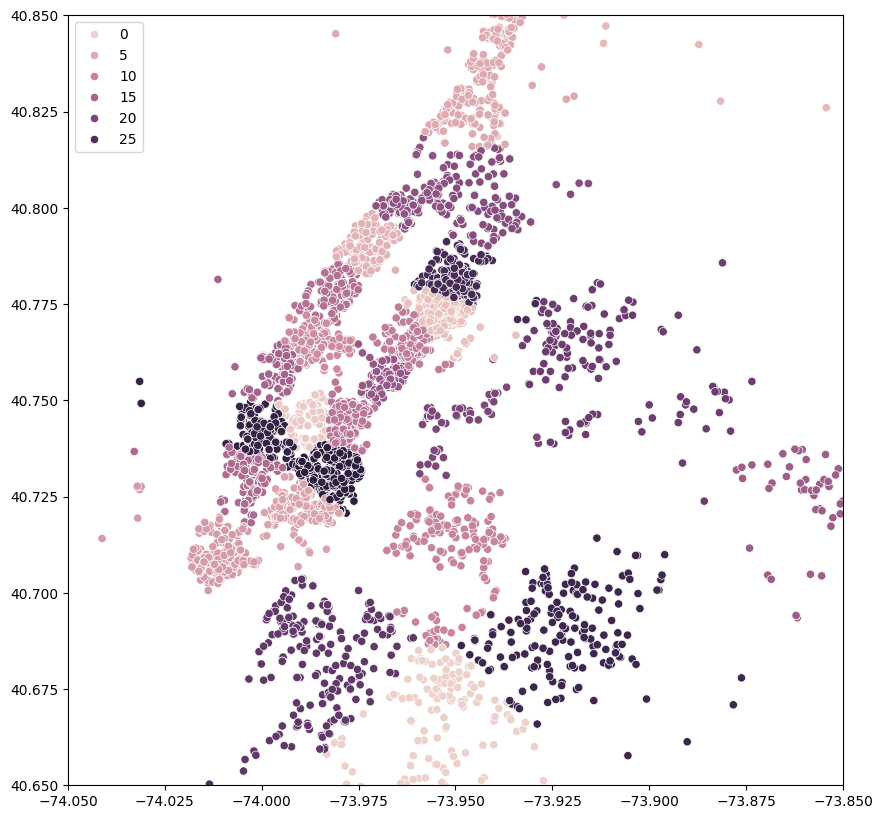

In [12]:
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(x=test['longitude'].values, y=test['latitude'].values, hue=test_predict_myKM)
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

На графике видно, что по методу, точки распределены по кластерам на основе цетроидов, то есть для каждого кластера есть некторая центральная точка.

## 5) Add the label of the cluster as a feature in the Lassi Regression with MinMaxScaller

In [13]:
train_X_KMeans = train_X.copy()
train_X_KMeans['KMeans'] = train_predict_myKM
test_X_KMeans = test_X.copy()
test_X_KMeans['KMeans'] = test_predict_myKM

In [14]:
min_max = MinMaxScaler()
train_X_KMeans[['bedrooms', 'bathrooms', 'KMeans']] = min_max.fit_transform(train_X_KMeans[['bedrooms', 'bathrooms', 'KMeans']])
test_X_KMeans[['bedrooms', 'bathrooms', 'KMeans']] = min_max.transform(test_X_KMeans[['bedrooms', 'bathrooms', 'KMeans']])

In [15]:
lasso_KM = Lasso(random_state=21)
lasso_KM.fit(train_X_KMeans, train_y)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,21
,selection,'cyclic'


## 6) Print the feature importance as the feature weight from the Lasso

In [16]:
importance_lasso_KM = pd.DataFrame({
    'name': train_X_KMeans.columns,
    'importance': abs(lasso_KM.coef_)
})
importance_lasso_KM.sort_values('importance')

,name,importance
18,Balcony,0.000000
5,CatsAllowed,2.221850
19,SwimmingPool,24.033062
15,OutdoorSpace,43.284868
23,KMeans,45.039253
12,Pre-War,49.572803
21,NewConstruction,51.520341
6,DogsAllowed,70.193793
9,NoFee,92.359338
14,RoofDeck,101.893728


## 7) Import K-means from sklearn and compare results

In [17]:
def draw_scatterplot(test_clustering, test_predict):
    fig = plt.figure(figsize=(10, 10))
    g = sns.scatterplot(x=test_clustering['longitude'].values, y=test_clustering['latitude'].values, hue=test_predict)
    g.set(xlim=(-74.05,-73.85))
    g.set(ylim=(40.65,40.85))

In [18]:
def cluster_scores_with_centroids(X, labels, centroids, name, table):
    silh = silhouette_score(X, labels)
    dist = distortion_score(X, labels, centroids)

    table[name] = [silh, dist]

    return table

In [23]:
lasso = Lasso()
lasso.fit(train_X, train_y)

train_predict = lasso.predict(train_X)
test_predict = lasso.predict(test_X)

lasso_MAE = [{
    'model' : 'Lasso',
    'train': mean_absolute_error(train_y, train_predict),
    'test': mean_absolute_error(test_y, test_predict)
}]

lasso_RMSE = [{
    'model' : 'Lasso',
    'train': root_mean_squared_error(train_y, train_predict),
    'test': root_mean_squared_error(test_y, test_predict)
}]

lasso_R2 = [{
    'model' : 'Lasso',
    'train': r2_score(train_y, train_predict),
    'test': r2_score(test_y, test_predict)
}]


def add_lasso_scores(model, train_y, train_X, test_y, test_X, name, lasso_MAE=lasso_MAE, lasso_RMSE=lasso_RMSE, lasso_R2=lasso_R2):
    lasso_MAE = lasso_MAE.append({
        'model': name, 
        'train': mean_absolute_error(train_y, model.predict(train_X)),
        'test': mean_absolute_error(test_y, model.predict(test_X))
    })

    lasso_RMSE = lasso_RMSE.append({
        'model': name, 
        'train': root_mean_squared_error(train_y, model.predict(train_X)),
        'test': root_mean_squared_error(test_y, model.predict(test_X))
    })

    lasso_R2 = lasso_R2.append({
        'model': name, 
        'train': r2_score(train_y, model.predict(train_X)),
        'test': r2_score(test_y, model.predict(test_X))
    })

In [24]:
sklearn_clustering_results = pd.DataFrame([], index=['Silhouette', 'Distortion'])

def compare_resulst(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_predict = model.predict(train_clustering)
    test_predict = model.predict(test_clustering)
    centroids = model.cluster_centers_

    # вычислить метрики
    cluster_scores_with_centroids(test_clustering, test_predict, centroids, name, table)
    print(sklearn_clustering_results)

    # отрисовка резульаттов на test
    draw_scatterplot(test_clustering, test_predict)

    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)
   
    

In [48]:
train_clustering = train[['longitude', 'latitude']]
test_clustering = test[['longitude', 'latitude']]

              KMeans
Silhouette  0.439737
Distortion  7.360390
                 name    importance
5         CatsAllowed      0.000000
18            Balcony      0.000000
15       OutdoorSpace     39.250376
6         DogsAllowed     53.598282
21    NewConstruction     54.004110
19       SwimmingPool     57.598057
12            Pre-War     60.147830
9               NoFee     74.743483
14           RoofDeck    101.816802
4      HardwoodFloors    101.907771
8          Dishwasher    124.147896
22            Terrace    141.460010
16         DiningRoom    145.134824
10  LaundryinBuilding    159.286583
20  LaundryInBuilding    172.776365
3            Elevator    184.186042
11      FitnessCenter    196.188796
17  HighSpeedInternet    214.281224
2      interest_level    432.495175
23             KMeans    432.737228
13      LaundryinUnit    433.118240
7             Doorman    554.098893
1            bedrooms   3907.523795
0           bathrooms  14513.689182


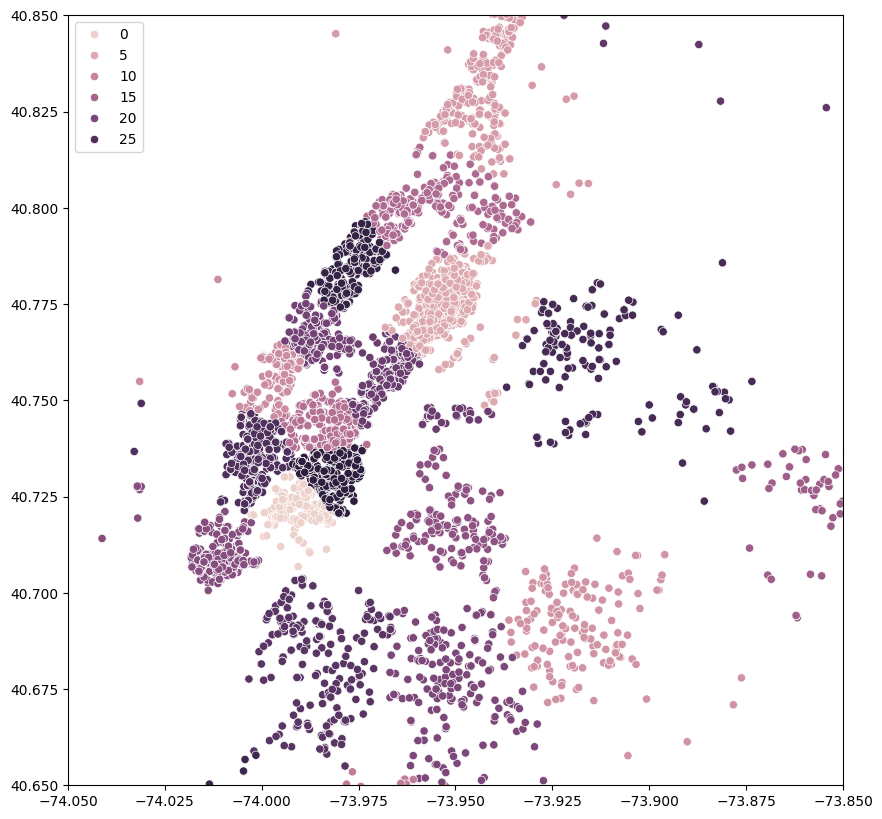

In [26]:
compare_resulst(KMeans(random_state=0, n_clusters=30), train_clustering, test_clustering, 'KMeans', sklearn_clustering_results, 'LonLat')

# 4. Do the same steps, but with the DBScan algorithm

### my DBSCAN

In [46]:
class myDBSCAN():
    def __init__(self, eps=0.001, min_samples=5, random_state = 21):
        self.eps = eps
        self.min_samples = min_samples
        self.random_state = random_state

    def find_neighbors(self, point, X):
        neighbors = []

        for i, x in enumerate(X):
            distance = np.linalg.norm(point - x)
            if distance <= self.eps:
                neighbors.append(i)
        
        return np.array(neighbors)


    def fit(self, X_fit):
        
        np.random.seed(self.random_state) # утсановка сида для случайных чисел

        if isinstance(X_fit, pd.DataFrame):
            X = X_fit.values
        else:
            X = X_fit

        n_samples = len(X)
        is_visit = np.zeros(n_samples) # метка того, была ли посещена точка
        cluster_labels = np.zeros(n_samples)
        current_cluster = -1

        for i in range(len(X)):
            print(f'{sum(is_visit)} / {n_samples}')
            if is_visit[i]:
                continue

            is_visit[i] = 1
            neighbors = self.find_neighbors(X[i], X)

            if len(neighbors) < self.min_samples:
                cluster_labels[i] = -1
            else:
                current_cluster += 1
                cluster_labels[i] = current_cluster
                queue = deque(neighbors)

                while queue:
                    current_idx = queue.popleft()

                    if not is_visit[current_idx]:
                        is_visit[current_idx] = 1
                        current_neighbors = self.find_neighbors(X[current_idx], X)

                        if len(current_neighbors) >= self.min_samples:
                            for neighbor_idx in current_neighbors:
                                if not is_visit[neighbor_idx]:
                                    queue.append(neighbor_idx)
                    
                    if cluster_labels[current_idx] == 0:
                        cluster_labels[current_idx] = current_cluster
        
        self.labels_ = cluster_labels
        self.X_ = X
        return self
    
    def predict(self, X_pred):
        if isinstance(X_pred, pd.DataFrame):
            X = X_pred.values
        else:
            X = X_pred

        self.fit(X)
        return self.labels_

In [49]:
myDB = myDBSCAN()
myDB.fit(test_clustering)

0.0 / 12086
8.0 / 12086
718.0 / 12086
719.0 / 12086
720.0 / 12086
741.0 / 12086
742.0 / 12086
1230.0 / 12086
1411.0 / 12086
1412.0 / 12086
2964.0 / 12086
3643.0 / 12086
3688.0 / 12086
3715.0 / 12086
3715.0 / 12086
3763.0 / 12086
3833.0 / 12086
3895.0 / 12086
3915.0 / 12086
3915.0 / 12086
3915.0 / 12086
3978.0 / 12086
3978.0 / 12086
3979.0 / 12086
4384.0 / 12086
4384.0 / 12086
4385.0 / 12086
4385.0 / 12086
4385.0 / 12086
4403.0 / 12086
4403.0 / 12086
4403.0 / 12086
4412.0 / 12086
4412.0 / 12086
4413.0 / 12086
4413.0 / 12086
4439.0 / 12086
4439.0 / 12086
4645.0 / 12086
4646.0 / 12086
4666.0 / 12086
4666.0 / 12086
4704.0 / 12086
4709.0 / 12086
4835.0 / 12086
4835.0 / 12086
4869.0 / 12086
5018.0 / 12086
5018.0 / 12086
5037.0 / 12086
5038.0 / 12086
5038.0 / 12086
5293.0 / 12086
5293.0 / 12086
5293.0 / 12086
5293.0 / 12086
5322.0 / 12086
5322.0 / 12086
5322.0 / 12086
5328.0 / 12086
5329.0 / 12086
5329.0 / 12086
5329.0 / 12086
5329.0 / 12086
5329.0 / 12086
5537.0 / 12086
5537.0 / 12086
5537.0

In [50]:
silhouette_score(test_clustering, myDB.labels_)

0.03633389271446298

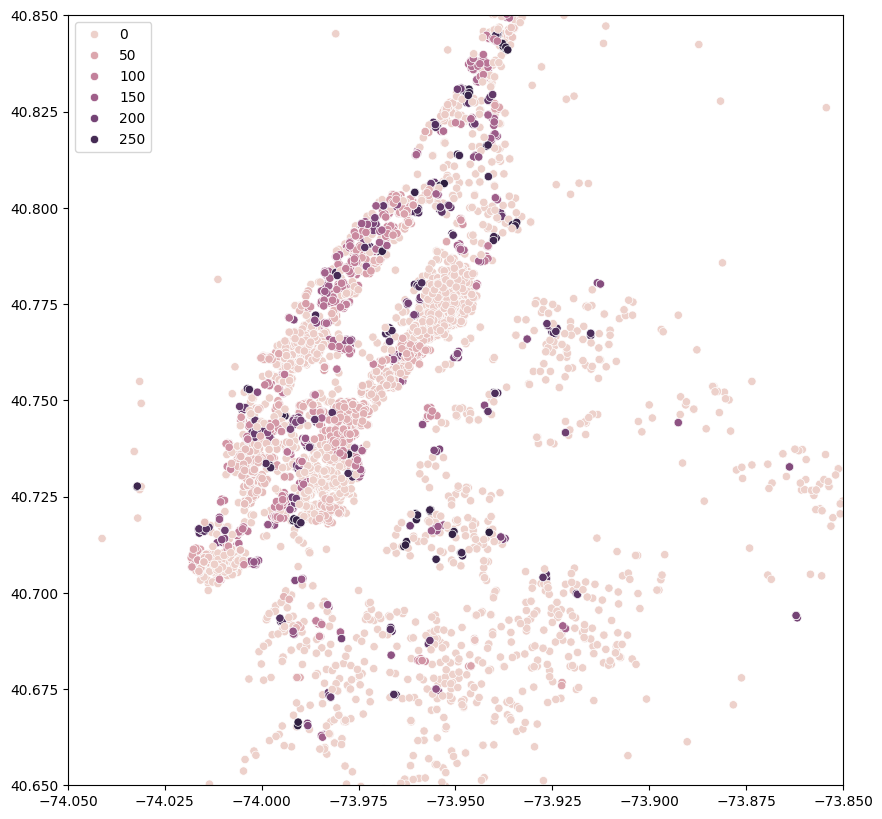

In [51]:
draw_scatterplot(test_clustering, myDB.labels_)

### sklearn DBSCAN

In [31]:
def add_cluster_scores(X, labels, name, table):
    silh = silhouette_score(X, labels)

    table[name] = [silh, None]

    return table

In [32]:
def compare_resulst_fit_predict(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_data = train_clustering.copy()
    test_data = test_clustering.copy()

    train_data['train'] = 1
    test_data['train'] = 0

    data = pd.concat([train_data, test_data]).reset_index(drop=True)

    data['cluster_labels'] = clustering_model.fit_predict(data[['latitude', 'longitude']])

    train_predict = data[data['train']==1]['cluster_labels'].values
    test_predict = data[data['train']==0]['cluster_labels'].values


    # вычислить метрики
    add_cluster_scores(test_clustering, test_predict, name, table)
    print(table)

    # отрисовка резульаттов на test
    draw_scatterplot(test_clustering, test_predict)

    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)
   

              KMeans    DBSCAN
Silhouette  0.439737 -0.173036
Distortion  7.360390       NaN
                 name    importance
5         CatsAllowed      0.000000
18            Balcony      0.000000
21    NewConstruction      2.537850
19       SwimmingPool     32.190972
15       OutdoorSpace     42.870277
12            Pre-War     57.663799
6         DogsAllowed     76.324478
9               NoFee     85.837356
14           RoofDeck    105.498339
8          Dishwasher    120.569585
22            Terrace    131.079977
4      HardwoodFloors    132.527035
16         DiningRoom    163.032013
10  LaundryinBuilding    180.661989
20  LaundryInBuilding    187.246518
3            Elevator    198.577559
11      FitnessCenter    204.720245
17  HighSpeedInternet    219.993345
2      interest_level    418.262781
13      LaundryinUnit    442.787874
7             Doorman    539.363898
23             DBSCAN    872.241584
1            bedrooms   3950.656297
0           bathrooms  14403.836789


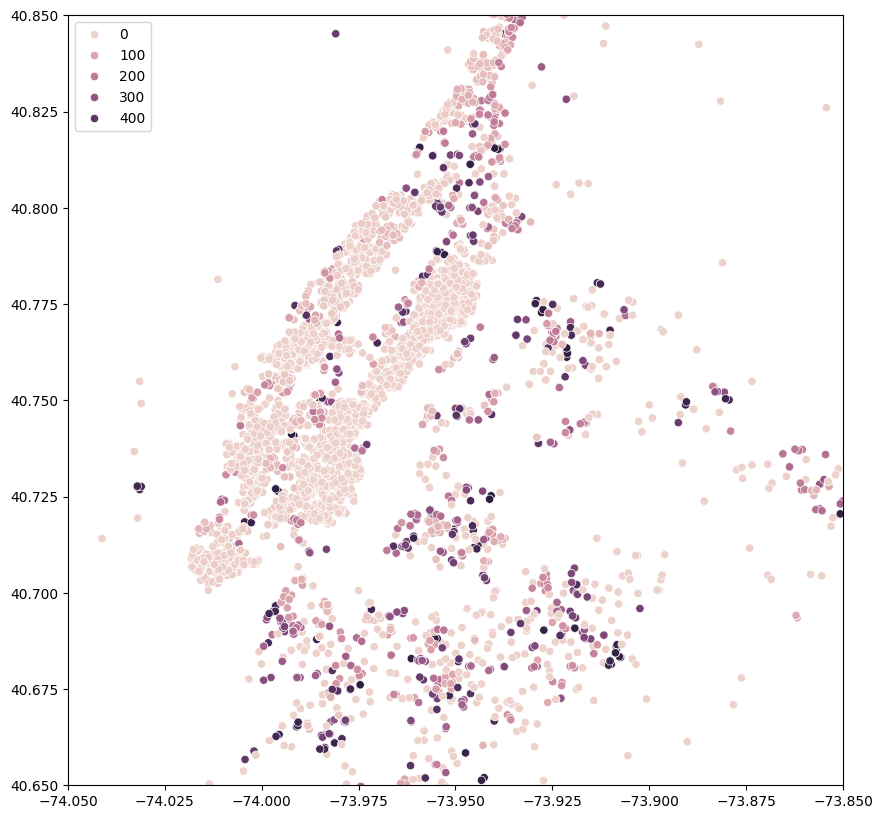

In [33]:
compare_resulst_fit_predict(DBSCAN(eps=0.001, min_samples=5),
                train_clustering,
                test_clustering,
                'DBSCAN',
                sklearn_clustering_results,
                'LonLat')

# 5. AgglomerativeClustering 

              KMeans    DBSCAN  AgglomerativeClustering
Silhouette  0.439737 -0.173036                  0.47741
Distortion  7.360390       NaN                      NaN
                       name    importance
5               CatsAllowed      0.000000
18                  Balcony      9.428246
12                  Pre-War     52.805653
6               DogsAllowed     55.288509
21          NewConstruction     63.075125
15             OutdoorSpace     67.182565
9                     NoFee     77.167438
4            HardwoodFloors     94.195030
19             SwimmingPool     94.951152
14                 RoofDeck    113.873869
8                Dishwasher    124.220406
22                  Terrace    138.883380
11            FitnessCenter    143.095655
10        LaundryinBuilding    150.827877
16               DiningRoom    170.868426
3                  Elevator    197.521050
20        LaundryInBuilding    203.769933
17        HighSpeedInternet    214.613894
13            LaundryinUnit    402

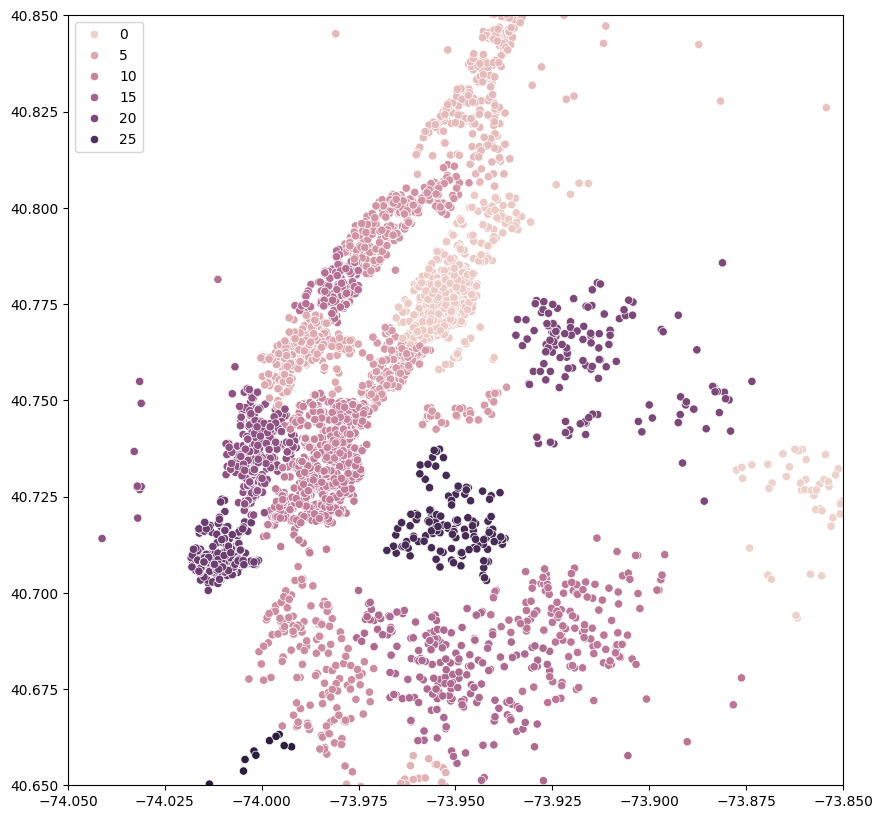

In [34]:
compare_resulst_fit_predict(AgglomerativeClustering(n_clusters=30),
                train_clustering,
                test_clustering,
                'AgglomerativeClustering',
                sklearn_clustering_results,
                'LonLat')

# 6. Gaussian Mixture

In [35]:
def compare_resulst_predict(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_predict = model.predict(train_clustering)
    test_predict = model.predict(test_clustering)

    # вычислить метрики
    add_cluster_scores(test_clustering, test_predict, name, table)
    print(table)

    # отрисовка резульаттов на test
    draw_scatterplot(test_clustering, test_predict)

    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)
   

              KMeans    DBSCAN  AgglomerativeClustering       GMM
Silhouette  0.439737 -0.173036                  0.47741  0.421032
Distortion  7.360390       NaN                      NaN       NaN
                 name    importance
18            Balcony      0.000000
5         CatsAllowed      2.342072
19       SwimmingPool     26.981348
23                GMM     29.426637
15       OutdoorSpace     42.126046
21    NewConstruction     45.717788
12            Pre-War     50.626655
6         DogsAllowed     71.011951
9               NoFee     93.195625
14           RoofDeck    101.558835
4      HardwoodFloors    107.880687
22            Terrace    132.669582
8          Dishwasher    134.408808
16         DiningRoom    147.806053
20  LaundryInBuilding    170.199711
10  LaundryinBuilding    177.575252
3            Elevator    196.584341
11      FitnessCenter    208.016424
17  HighSpeedInternet    222.405597
2      interest_level    425.613243
13      LaundryinUnit    438.621927
7         

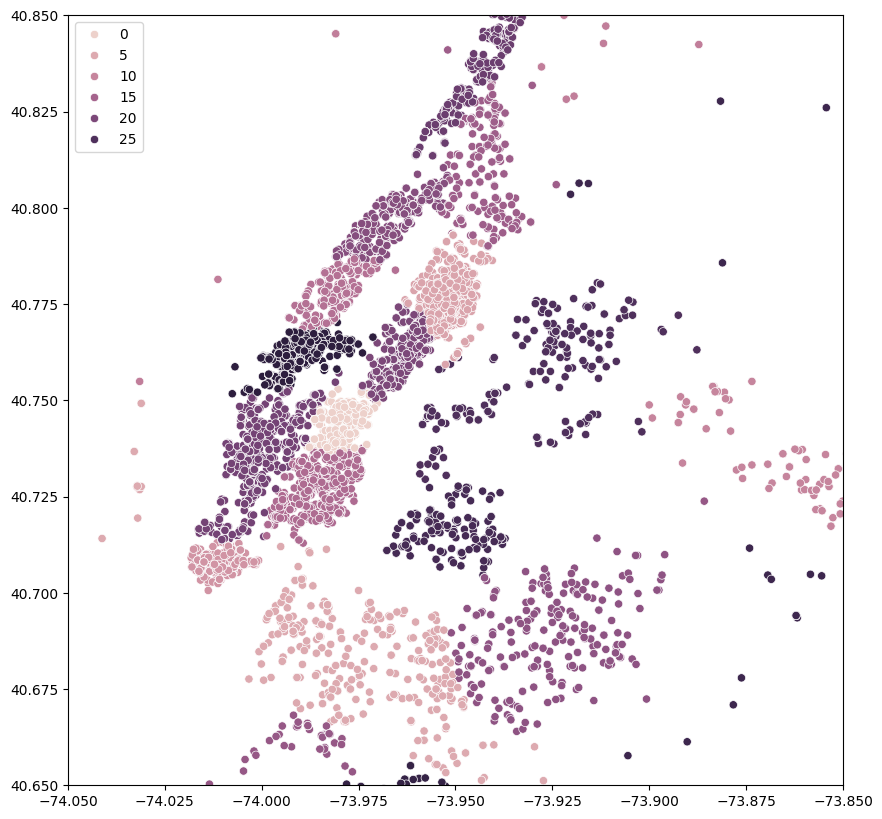

In [36]:
compare_resulst_predict(
    GaussianMixture(n_components=30),
    train_clustering, 
    test_clustering,
    'GMM',
    sklearn_clustering_results,
    'LonLat'
)

# 7. Try all these algorithms with different sets of features.

In [37]:
train_clustering = train_X[['bedrooms', 'bathrooms', 'interest_level']]
test_clustering = test_X[['bedrooms', 'bathrooms', 'interest_level']]
clustering_results_bed_bath_int = pd.DataFrame([], index=['Silhouette', 'Distortion'])

### Kmeans

In [39]:
def compare_resulst(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_predict = model.predict(train_clustering)
    test_predict = model.predict(test_clustering)
    centroids = model.cluster_centers_

    # вычислить метрики
    cluster_scores_with_centroids(test_clustering, test_predict, centroids, name, table)
    print(table)


    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)

compare_resulst(KMeans(random_state=0, n_clusters=30), train_clustering, test_clustering, 'KMeans', clustering_results_bed_bath_int, 'bed bath int')

                KMeans
Silhouette    0.965563
Distortion  186.030573
                 name    importance
18            Balcony      0.000000
5         CatsAllowed      3.001644
19       SwimmingPool     30.474564
15       OutdoorSpace     38.939712
12            Pre-War     45.598588
21    NewConstruction     47.179904
6         DogsAllowed     79.467944
4      HardwoodFloors     95.855309
9               NoFee     96.258398
14           RoofDeck     98.437120
22            Terrace    127.770166
16         DiningRoom    143.019439
8          Dishwasher    143.047129
20  LaundryInBuilding    165.942610
10  LaundryinBuilding    173.609476
3            Elevator    188.797138
11      FitnessCenter    205.894545
17  HighSpeedInternet    217.436374
13      LaundryinUnit    429.450811
2      interest_level    538.226712
7             Doorman    565.951671
23             KMeans    772.147471
1            bedrooms   3566.855034
0           bathrooms  13750.737963


### DBSCAN

In [40]:
def compare_resulst_fit_predict(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_data = train_clustering.copy()
    test_data = test_clustering.copy()

    train_data['train'] = 1
    test_data['train'] = 0

    data = pd.concat([train_data, test_data]).reset_index(drop=True)

    data['cluster_labels'] = clustering_model.fit_predict(data[['bedrooms', 'bathrooms', 'interest_level']])

    train_predict = data[data['train']==1]['cluster_labels'].values
    test_predict = data[data['train']==0]['cluster_labels'].values


    # вычислить метрики
    add_cluster_scores(test_clustering, test_predict, name, table)
    print(table)


    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)

compare_resulst_fit_predict(DBSCAN(eps=0.001, min_samples=5),
                train_clustering,
                test_clustering,
                'DBSCAN',
                clustering_results_bed_bath_int,
                'bed bath int')

                KMeans    DBSCAN
Silhouette    0.965563  0.997709
Distortion  186.030573       NaN
                 name    importance
18            Balcony      0.000000
5         CatsAllowed      1.018684
19       SwimmingPool     29.662451
21    NewConstruction     42.641561
15       OutdoorSpace     43.358430
12            Pre-War     47.396771
6         DogsAllowed     74.483375
9               NoFee     94.916303
14           RoofDeck    100.858575
4      HardwoodFloors    105.959009
22            Terrace    123.871637
8          Dishwasher    135.987027
16         DiningRoom    141.387599
20  LaundryInBuilding    172.189830
10  LaundryinBuilding    179.844212
3            Elevator    195.433594
11      FitnessCenter    212.999742
17  HighSpeedInternet    219.297263
13      LaundryinUnit    435.907228
2      interest_level    482.948452
7             Doorman    565.895402
23             DBSCAN    769.376690
1            bedrooms   3743.000521
0           bathrooms  13884.796482


### AgglomerativeClustering

In [41]:
compare_resulst_fit_predict(AgglomerativeClustering(n_clusters=30),
                train_clustering,
                test_clustering,
                'AgglomerativeClustering',
                clustering_results_bed_bath_int,
                'bed bath int')

                KMeans    DBSCAN  AgglomerativeClustering
Silhouette    0.965563  0.997709                 0.958823
Distortion  186.030573       NaN                      NaN
                       name    importance
18                  Balcony      0.000000
5               CatsAllowed      1.738158
23  AgglomerativeClustering     21.088361
19             SwimmingPool     26.145297
15             OutdoorSpace     41.909650
21          NewConstruction     49.836134
12                  Pre-War     50.221913
6               DogsAllowed     69.385818
9                     NoFee     92.743817
14                 RoofDeck    101.945051
4            HardwoodFloors    107.448371
22                  Terrace    132.251596
8                Dishwasher    134.682021
16               DiningRoom    147.218363
20        LaundryInBuilding    168.588079
10        LaundryinBuilding    176.932634
3                  Elevator    196.834636
11            FitnessCenter    208.295467
17        HighSpeedInternet 

### Gaussine Mixture

In [42]:
def compare_resulst_predict(clustering_model, train_clustering, test_clustering, name, table, features):
    #обучили модель
    model = clustering_model
    model.fit(train_clustering)
    
    # предсказания на train и test
    train_predict = model.predict(train_clustering)
    test_predict = model.predict(test_clustering)

    # вычислить метрики
    add_cluster_scores(test_clustering, test_predict, name, table)
    print(table)


    # добавление признака и нормализация данных
    train_lasso_X = train_X.copy()
    train_lasso_X[name] = train_predict
    test_lasso_X = test_X.copy()
    test_lasso_X[name] = test_predict

    min_max = MinMaxScaler()
    train_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.fit_transform(train_lasso_X[['bedrooms', 'bathrooms', name]])
    test_lasso_X[['bedrooms', 'bathrooms', name]] = min_max.transform(test_lasso_X[['bedrooms', 'bathrooms', name]])

    lasso = Lasso()
    lasso.fit(train_lasso_X, train_y)
    add_lasso_scores(lasso, train_y, train_lasso_X, test_y, test_lasso_X, f'Lasso {features} {name}')

    #важность признаков
    importance_lasso = pd.DataFrame({
        'name': train_lasso_X.columns,
        'importance': abs(lasso.coef_)
    })
    importance_lasso.sort_values('importance', inplace=True)
    print(importance_lasso)
   

compare_resulst_predict(
    GaussianMixture(n_components=30),
    train_clustering, 
    test_clustering,
    'GMM',
    clustering_results_bed_bath_int,
    'bed bath int'
)

                KMeans    DBSCAN  AgglomerativeClustering       GMM
Silhouette    0.965563  0.997709                 0.958823  0.955463
Distortion  186.030573       NaN                      NaN       NaN
                 name    importance
5         CatsAllowed      0.000000
18            Balcony      0.000000
19       SwimmingPool     30.500162
15       OutdoorSpace     45.546371
21    NewConstruction     46.147810
12            Pre-War     46.199401
6         DogsAllowed     75.726069
9               NoFee     96.148316
4      HardwoodFloors    100.941909
14           RoofDeck    102.440304
22            Terrace    132.332938
8          Dishwasher    139.961863
16         DiningRoom    143.345724
20  LaundryInBuilding    165.390311
10  LaundryinBuilding    176.655319
3            Elevator    191.016773
11      FitnessCenter    210.850557
17  HighSpeedInternet    224.026077
13      LaundryinUnit    435.714031
2      interest_level    516.367621
7             Doorman    563.070329
23  

# 8. Compare the results with the complexity, speed and accuracy of these methods.

In [43]:
pd.DataFrame(lasso_MAE)

,model,train,test
0,Lasso,690.461632,679.440326
1,Lasso LonLat KMeans,682.133312,670.294593
2,Lasso LonLat DBSCAN,680.860945,668.401823
3,Lasso LonLat AgglomerativeClustering,675.282356,661.888588
4,Lasso LonLat GMM,690.779063,679.572829
5,Lasso bed bath int KMeans,685.561732,674.870138
6,Lasso bed bath int DBSCAN,689.795379,678.474404
7,Lasso bed bath int AgglomerativeClustering,690.675416,679.473776
8,Lasso bed bath int GMM,688.628823,676.816532


In [44]:
pd.DataFrame(lasso_RMSE)

,model,train,test
0,Lasso,1004.920458,972.332690
1,Lasso LonLat KMeans,996.843003,962.927659
2,Lasso LonLat DBSCAN,993.826502,962.048566
3,Lasso LonLat AgglomerativeClustering,990.827598,955.050295
4,Lasso LonLat GMM,1005.088732,972.013245
5,Lasso bed bath int KMeans,998.599460,966.014546
6,Lasso bed bath int DBSCAN,1001.935335,967.752075
7,Lasso bed bath int AgglomerativeClustering,1005.098564,972.138385
8,Lasso bed bath int GMM,1001.380311,968.046810


In [45]:
pd.DataFrame(lasso_R2)

,model,train,test
0,Lasso,0.605792,0.601301
1,Lasso LonLat KMeans,0.612104,0.608977
2,Lasso LonLat DBSCAN,0.614448,0.609690
3,Lasso LonLat AgglomerativeClustering,0.616771,0.615348
4,Lasso LonLat GMM,0.605660,0.601563
5,Lasso bed bath int KMeans,0.610735,0.606466
6,Lasso bed bath int DBSCAN,0.608130,0.605049
7,Lasso bed bath int AgglomerativeClustering,0.605652,0.601460
8,Lasso bed bath int GMM,0.608564,0.604808


K-means и DBSCAN наиболее простые методы в плане алгоритма и его работы, и в целом считаются быстро. 

AgglomerativeClustering - работает долго и при этом метрики плоховаты. В сравнении с другими методами более ресурсно затраный.

GMM - показало лучшие метрики, и неплохую скорость, скорее всего благодаря распределению данных таким образом, то элепсоидной описание подходит гораздно лучше.